In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_csv("../data/tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [4]:
import numpy as np 
df.replace(-999, np.nan, inplace=True)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,2015-01-05,1


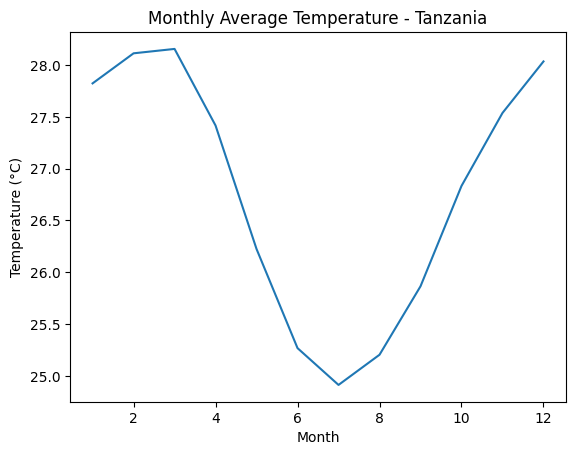

In [6]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature - Tanzania")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### 🌡️ Monthly Temperature Pattern - Tanzania
- **Warmest months**: February–March (~28.2°C).  
- **Coolest months**: June–July (~25.0°C).  
- **Seasonal cycle**: Clear oscillation between warmer early-year and cooler mid-year phases.  

**Takeaway**: Tanzania’s climate shows **moderate seasonal variation**, never straying far from the tropical comfort zone.


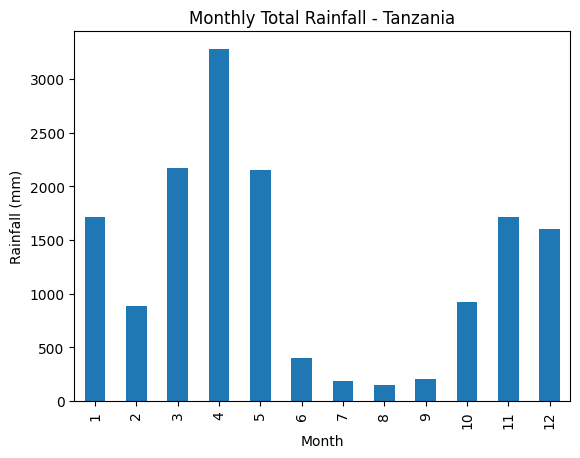

In [7]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall - Tanzania")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

### 🌧️ Monthly Rainfall Pattern - Tanzania
- **Peak rainfall**: April (>3000 mm), with strong rains also in March, May, Nov, Dec.  
- **Dry season**: June to September, minimal precipitation.  
- **Bimodal rhythm**: Two wet seasons (long rains in Mar–May, short rains in Nov to Dec).  

**Takeaway**: Rainfall is **highly seasonal**, shaping agriculture and water cycles more than temperature extremes.


In [8]:
extreme_days = df[df["T2M_MAX"] > 35]
len(extreme_days)


0

### 🔥 Extreme Heat Days - Tanzania
- **Observation**: 0 days exceeded 35°C threshold.  
- **Implication**: Climate avoids dangerous heat extremes.  
- **Stability**: Reinforces Tanzania’s resilience against extreme heat events.  

**Key takeaway**: Tanzania’s climate is **thermally stable**, with rainfall variability as the dominant driver.


In [13]:
df.to_csv("../data/tanzania_clean.csv", index=False)